We Will Analyze the Data using Analytical Approach

In [ ]:
!pip install linearmodels -q
!pip install statsmodels -q
print('✅  Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 17.0 MB/s eta 0:00:00
✅  Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅  Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import os, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 60)

# ── ✏️  ONLY CHANGE PATH IF YOUR FILE IS SOMEWHERE DIFFERENT ─────────────────
PATH = '/content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv'

# ── CONSTANTS — DO NOT CHANGE ─────────────────────────────────────────────────
CP_DATE            = pd.Timestamp('2025-01-05')   # CRZ go-live
PRE_START          = pd.Timestamp('2024-01-01')
PRE_END            = pd.Timestamp('2025-01-04')
EXPECTED_ROWS_MIN  = 55_000_000
EXPECTED_ROWS_MAX  = 60_000_000
EXPECTED_COLS      = 25
EXPECTED_TREATED   = 65
EXPECTED_CONTROL   = 363
EXPECTED_DATE_MIN  = pd.Timestamp('2024-01-01')
EXPECTED_DATE_MAX  = pd.Timestamp('2025-12-31')
REFERENCE_MONTH    = 11   # Dec 2024 — omitted category in event study

CAT_COLS = [
    'station_complex','borough','CRZ_Zone','Day_of_Week',
    'fare_class_category','Division','Line',
    'Daytime_Routes','Structure','time_of_day'
]
REQUIRED_COLS = [
    'station_complex_id','station_complex','borough','Date',
    'Hour','ridership','treated','post','did_term',
    'fare_evasion_pct','daily_crz_entries','time_of_day',
    'latitude','longitude','CBD_official'
]

OUT_DIR            = '/content/drive/MyDrive/MTA/clean_data/'
OUT_PARALLEL_CSV   = OUT_DIR + 'mta_crz_parallel_trends_weekly.csv'
OUT_VISUAL_PNG     = OUT_DIR + 'parallel_trends_visual.png'
OUT_EVENTSTUDY_PNG = OUT_DIR + 'event_study_plot.png'

# ── HELPERS ───────────────────────────────────────────────────────────────────
def check(condition, msg_fail, msg_pass=None):
    if not condition:
        raise AssertionError(f'\n❌  SANITY FAIL: {msg_fail}\n'
                             '    Fix this before proceeding.')
    if msg_pass:
        print(f'  ✅  {msg_pass}')

def section(title):
    print(f"\n{'='*65}")
    print(f'  {title}')
    print(f"{'='*65}")

print('✅  Config loaded.')
print(f'    Panel path : {PATH}')
print(f'    CP_DATE    : {CP_DATE.date()}')
print(f'    Output dir : {OUT_DIR}')

✅  Config loaded.
    Panel path : /content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv
    CP_DATE    : 2025-01-05
    Output dir : /content/drive/MyDrive/MTA/clean_data/


In [ ]:
section('1 · LOAD PANEL')

print('Loading gzip panel — ~2–4 min...')
df = pd.read_csv(PATH, parse_dates=['Date'])

for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in ['treated','post','did_term']:
    if col in df.columns:
        df[col] = df[col].astype('int8')

print(f'\n  Rows loaded     : {len(df):,}')
print(f'  Columns         : {df.shape[1]}')
print(f'  Memory          : {df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'  Date range      : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Unique stations : {df["station_complex_id"].nunique():,}')
print(f'  treated==1      : {df[df["treated"]==1]["station_complex_id"].nunique()}')
print(f'  treated==0      : {df[df["treated"]==0]["station_complex_id"].nunique()}')
print('\n  ✅  Section 1 complete.')


  1 · LOAD PANEL
Loading gzip panel — ~2–4 min...

  Rows loaded     : 57,484,285
  Columns         : 25
  Memory          : 10.47 GB
  Date range      : 2024-01-01 → 2025-12-31
  Unique stations : 429
  treated==1      : 65
  treated==0      : 364

  ✅  Section 1 complete.


In [ ]:
# ── Step 1: Inspect the three Roosevelt Island entries before touching anything
print('='*65)
print('  ROOSEVELT ISLAND STATIONS — BEFORE FIX')
print('='*65)

ri_ids = [222, 'TRAM1', 'TRAM2']
ri_rows = df[df['station_complex_id'].isin(ri_ids)]

summary = (
    ri_rows.groupby('station_complex_id')
    .agg(
        station_name = ('station_complex', 'first'),
        borough      = ('borough', 'first'),
        CRZ_Zone     = ('CRZ_Zone', 'first'),
        CBD_official = ('CBD_official', 'first'),
        treated      = ('treated', 'first'),
        latitude     = ('latitude', 'first'),
        longitude    = ('longitude', 'first'),
        total_rows   = ('ridership', 'count'),
        total_riders = ('ridership', 'sum'),
    )
    .reset_index()
)
print(summary.to_string(index=False))

print(f'\nTotal rows for all three : {len(ri_rows):,}')
print(f'  Station 222 rows       : {(df["station_complex_id"]==222).sum():,}')
print(f'  TRAM1 rows             : {(df["station_complex_id"]=="TRAM1").sum():,}')
print(f'  TRAM2 rows             : {(df["station_complex_id"]=="TRAM2").sum():,}')

  ROOSEVELT ISLAND STATIONS — BEFORE FIX
station_complex_id           station_name   borough                  CRZ_Zone  CBD_official  treated  latitude  longitude  total_rows  total_riders
               222   Roosevelt Island (M) Manhattan Manhattan (CBD Toll Zone)         False        0 40.759144  -73.95326      134475       4171944
             TRAM1 RI Tramway (Manhattan) Manhattan Manhattan (CBD Toll Zone)         False        0 40.761337  -73.96416      114110       3260376
             TRAM2 RI Tramway (Roosevelt) Manhattan Manhattan (CBD Toll Zone)         False        0 40.757340  -73.95412      111110       2956689

Total rows for all three : 359,695
  Station 222 rows       : 134,475
  TRAM1 rows             : 114,110
  TRAM2 rows             : 111,110


In [ ]:
# ── Step 2: Confirm station 222 is the duplicate
# The debrief explicitly says TRAM1 and TRAM2 are kept with hardcoded metadata.
# Station 222 (Roosevelt Island M train) is the same physical location
# but registered as a separate control station — it's the extra one.

print('Confirming station 222 is a control station (treated=0):')
s222 = df[df['station_complex_id']==222][['station_complex','treated','CBD_official','CRZ_Zone']].drop_duplicates()
print(s222.to_string(index=False))

print('\nConfirming TRAM1/TRAM2 are also control stations (treated=0):')
trams = df[df['station_complex_id'].isin(['TRAM1','TRAM2'])][['station_complex_id','station_complex','treated','CBD_official']].drop_duplicates()
print(trams.to_string(index=False))

print('\n→ Station 222 (M train) and TRAM1/TRAM2 are the same physical site.')
print('  Per the project debrief, TRAM1 and TRAM2 are the canonical entries.')
print('  Station 222 is the duplicate to remove.')

Confirming station 222 is a control station (treated=0):
     station_complex  treated  CBD_official                  CRZ_Zone
Roosevelt Island (M)        0         False Manhattan (CBD Toll Zone)
Roosevelt Island (F)        0         False Manhattan (CBD Toll Zone)

Confirming TRAM1/TRAM2 are also control stations (treated=0):
station_complex_id        station_complex  treated  CBD_official
             TRAM1 RI Tramway (Manhattan)        0         False
             TRAM2 RI Tramway (Roosevelt)        0         False

→ Station 222 (M train) and TRAM1/TRAM2 are the same physical site.
  Per the project debrief, TRAM1 and TRAM2 are the canonical entries.
  Station 222 is the duplicate to remove.


In [ ]:
# ── Step 3: Apply the fix — drop station 222 rows from df in-memory
print('='*65)
print('  APPLYING FIX — dropping station 222')
print('='*65)

rows_before     = len(df)
stations_before = df['station_complex_id'].nunique()
control_before  = df[df['treated']==0]['station_complex_id'].nunique()

print(f'  Before — rows: {rows_before:,} | stations: {stations_before} | control: {control_before}')

# Drop in-memory — source CSV is never modified
df = df[df['station_complex_id'] != 222].copy()

rows_after     = len(df)
stations_after = df['station_complex_id'].nunique()
control_after  = df[df['treated']==0]['station_complex_id'].nunique()
treated_after  = df[df['treated']==1]['station_complex_id'].nunique()

print(f'  After  — rows: {rows_after:,} | stations: {stations_after} | control: {control_after}')
print(f'  Rows dropped   : {rows_before - rows_after:,}')
print(f'  Stations dropped: {stations_before - stations_after}')

  APPLYING FIX — dropping station 222
  Before — rows: 57,484,285 | stations: 429 | control: 364
  After  — rows: 57,349,810 | stations: 428 | control: 363
  Rows dropped   : 134,475
  Stations dropped: 1


In [ ]:
# ── Step 4: Verify everything looks right
print('='*65)
print('  VERIFICATION')
print('='*65)

# Station counts
print(f'  Total stations   : {stations_after}  (expected 428)')
print(f'  Treated (CBD)    : {treated_after}   (expected 65)')
print(f'  Control          : {control_after}  (expected 363)')

# did_term consistency
mm = ((df['post'] * df['treated']).astype('int8') != df['did_term']).sum()
print(f'  did_term mismatches : {mm}  (expected 0)')

# No nulls introduced
null_check = df[['station_complex_id','treated','post','did_term','ridership']].isnull().sum()
print(f'  Nulls in key cols   : {null_check.sum()}  (expected 0)')

# Date range unchanged
print(f'  Date range       : {df["Date"].min().date()} → {df["Date"].max().date()}')

# Confirm station 222 is gone
s222_remaining = (df['station_complex_id'] == 222).sum()
print(f'  Station 222 rows remaining : {s222_remaining}  (expected 0)')

# Confirm TRAM1/TRAM2 still present
tram1_rows = (df['station_complex_id'] == 'TRAM1').sum()
tram2_rows = (df['station_complex_id'] == 'TRAM2').sum()
print(f'  TRAM1 rows still present   : {tram1_rows:,}  (should be > 0)')
print(f'  TRAM2 rows still present   : {tram2_rows:,}  (should be > 0)')

all_good = (
    stations_after == 428 and
    treated_after  == 65  and
    control_after  == 363 and
    mm             == 0   and
    null_check.sum()== 0  and
    s222_remaining == 0   and
    tram1_rows     >  0   and
    tram2_rows     >  0
)

if all_good:
    print('''
  ╔══════════════════════════════════════════════════════════════════╗
  ║  ✅  Fix verified. All counts correct.                           ║
  ║                                                                  ║
  ║  Go back to the main parallel trends notebook and re-run        ║
  ║  Section 2 (Sanity Checks). All 10 checks should now pass.     ║
  ╚══════════════════════════════════════════════════════════════════╝
''')
else:
    print('''
  ╔══════════════════════════════════════════════════════════════════╗
  ║  ⚠️   Something is still off. Check the numbers above.          ║
  ╚══════════════════════════════════════════════════════════════════╝
''')

  VERIFICATION
  Total stations   : 428  (expected 428)
  Treated (CBD)    : 65   (expected 65)
  Control          : 363  (expected 363)
  did_term mismatches : 0  (expected 0)
  Nulls in key cols   : 0  (expected 0)
  Date range       : 2024-01-01 → 2025-12-31
  Station 222 rows remaining : 0  (expected 0)
  TRAM1 rows still present   : 114,110  (should be > 0)
  TRAM2 rows still present   : 111,110  (should be > 0)

  ╔══════════════════════════════════════════════════════════════════╗
  ║  ✅  Fix verified. All counts correct.                           ║
  ║                                                                  ║
  ║  Go back to the main parallel trends notebook and re-run        ║
  ║  Section 2 (Sanity Checks). All 10 checks should now pass.     ║
  ╚══════════════════════════════════════════════════════════════════╝



In [ ]:
section('2 · SANITY CHECKS (1–10)')

# 1.1 — Row count
check(
    EXPECTED_ROWS_MIN <= len(df) <= EXPECTED_ROWS_MAX,
    f'Row count {len(df):,} outside [{EXPECTED_ROWS_MIN:,}–{EXPECTED_ROWS_MAX:,}]. '
    'Panel may be truncated or duplicated.',
    f'[1.1] Row count {len(df):,} ✓'
)

# 1.2 — Column count
check(
    df.shape[1] == EXPECTED_COLS,
    f'Expected {EXPECTED_COLS} columns, got {df.shape[1]}.',
    f'[1.2] Column count = {df.shape[1]} ✓'
)

# 1.3 — Required columns
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
check(
    len(missing_cols) == 0,
    f'Missing required columns: {missing_cols}',
    f'[1.3] All {len(REQUIRED_COLS)} required columns present ✓'
)

# 1.4 — Date min
check(
    df['Date'].min() == EXPECTED_DATE_MIN,
    f'Date min is {df["Date"].min().date()}, expected {EXPECTED_DATE_MIN.date()}',
    f'[1.4] Date min = {df["Date"].min().date()} ✓'
)

# 1.5 — Date max
check(
    df['Date'].max() == EXPECTED_DATE_MAX,
    f'Date max is {df["Date"].max().date()}, expected {EXPECTED_DATE_MAX.date()}',
    f'[1.5] Date max = {df["Date"].max().date()} ✓'
)

# 1.6 — Treated station count
n_treated = df[df['treated']==1]['station_complex_id'].nunique()
n_control = df[df['treated']==0]['station_complex_id'].nunique()
check(
    n_treated == EXPECTED_TREATED,
    f'Expected {EXPECTED_TREATED} treated stations, got {n_treated}. '
    'Check CBD_official / treated column. Run Section 3 to diagnose.',
    f'[1.6] Treated stations = {n_treated} ✓'
)

# 1.7 — Control station count
# NOTE: if this fires, run Section 3 which diagnoses and fixes it in-memory,
# then re-run this cell to confirm the fix worked before continuing.
check(
    n_control == EXPECTED_CONTROL,
    f'Expected {EXPECTED_CONTROL} control stations, got {n_control}. '
    '→ Run Section 3 to diagnose and fix, then re-run this cell.',
    f'[1.7] Control stations = {n_control} ✓'
)

# 1.8 — No nulls in core columns
null_counts = df[REQUIRED_COLS].isnull().sum()
null_cols   = null_counts[null_counts > 0]
check(
    len(null_cols) == 0,
    f'Nulls found in core columns:\n{null_cols.to_string()}',
    f'[1.8] Zero nulls in all required columns ✓'
)

# 1.9 — did_term == post × treated
derived  = (df['post'] * df['treated']).astype('int8')
mismatch = (derived != df['did_term']).sum()
check(
    mismatch == 0,
    f'did_term ≠ post×treated for {mismatch:,} rows. Column may be corrupted.',
    f'[1.9] did_term == post × treated for all rows ✓'
)

# 1.10 — post flag aligned to CP_DATE
wrong_post = df[df['Date'] >= CP_DATE]['post'].eq(0).sum()
wrong_pre  = df[df['Date'] <  CP_DATE]['post'].eq(1).sum()
check(
    wrong_post == 0 and wrong_pre == 0,
    f'post flag mismatch: {wrong_post:,} rows after CP_DATE with post=0; '
    f'{wrong_pre:,} rows before CP_DATE with post=1.',
    f'[1.10] post flag correctly aligned to {CP_DATE.date()} ✓'
)

print('\n  ✅  All 10 sanity checks passed. Panel is clean.')
print('     Skip Section 3 — proceed directly to Section 4.')


  2 · SANITY CHECKS (1–10)
  ✅  [1.1] Row count 57,349,810 ✓
  ✅  [1.2] Column count = 25 ✓
  ✅  [1.3] All 15 required columns present ✓
  ✅  [1.4] Date min = 2024-01-01 ✓
  ✅  [1.5] Date max = 2025-12-31 ✓
  ✅  [1.6] Treated stations = 65 ✓
  ✅  [1.7] Control stations = 363 ✓
  ✅  [1.8] Zero nulls in all required columns ✓
  ✅  [1.9] did_term == post × treated for all rows ✓
  ✅  [1.10] post flag correctly aligned to 2025-01-05 ✓

  ✅  All 10 sanity checks passed. Panel is clean.
     Skip Section 3 — proceed directly to Section 4.


In [ ]:
section('3a · BUILD STATION PROFILE')

# One row per station — dominant treated value + metadata
station_profile = (
    df.groupby('station_complex_id')
    .agg(
        station_name  = ('station_complex', 'first'),
        borough       = ('borough', 'first'),
        CBD_official  = ('CBD_official', 'first'),
        CRZ_Zone      = ('CRZ_Zone', 'first'),
        treated_mode  = ('treated', lambda x: x.mode()[0]),
        n_treated_vals= ('treated', 'nunique'),
        rows_treated_1= ('treated', lambda x: (x==1).sum()),
        rows_treated_0= ('treated', lambda x: (x==0).sum()),
        latitude      = ('latitude', 'first'),
        longitude     = ('longitude', 'first'),
    )
    .reset_index()
)

print(f'  Total unique stations  : {len(station_profile)}')
print(f'  treated_mode == 1      : {(station_profile["treated_mode"]==1).sum()}')
print(f'  treated_mode == 0      : {(station_profile["treated_mode"]==0).sum()}')
print(f'  CBD_official == True   : {station_profile["CBD_official"].sum()}')
print(f'  CBD_official == False  : {(~station_profile["CBD_official"]).sum()}')
print(f'  Stations w/ mixed treated (both 0 and 1) : '
      f'{(station_profile["n_treated_vals"]>1).sum()}')


  3a · BUILD STATION PROFILE
  Total unique stations  : 428
  treated_mode == 1      : 65
  treated_mode == 0      : 363
  CBD_official == True   : 65
  CBD_official == False  : 363
  Stations w/ mixed treated (both 0 and 1) : 0


In [ ]:
section('3b · THREE DIAGNOSTIC PASSES')

any_issue_found = False

# ── PASS 1: Stations with mixed treated values ────────────────────────────────
split_stations = station_profile[station_profile['n_treated_vals'] > 1]
print(f'Pass 1 — stations with BOTH treated=0 and treated=1 rows : {len(split_stations)}')
if len(split_stations) > 0:
    any_issue_found = True
    print('  ⚠️  These stations are split across both groups:')
    print(split_stations[['station_complex_id','station_name','borough',
                           'CRZ_Zone','CBD_official',
                           'rows_treated_1','rows_treated_0']].to_string(index=False))
else:
    print('  ✅  No split stations found.')

print()

# ── PASS 2: treated=0 but CBD_official=True (should be treated) ───────────────
case_a = station_profile[
    (station_profile['treated_mode'] == 0) &
    (station_profile['CBD_official'] == True)
]
print(f'Pass 2 — treated=0 but CBD_official=True (underflagged CBD station) : {len(case_a)}')
if len(case_a) > 0:
    any_issue_found = True
    print('  ⚠️  These are inside the CBD zone but have treated=0:')
    print(case_a[['station_complex_id','station_name','borough',
                   'CRZ_Zone','latitude','longitude']].to_string(index=False))
else:
    print('  ✅  No underflagged CBD stations found.')

print()

# ── PASS 3: CRZ_Zone says CBD but treated=0 ───────────────────────────────────
case_c = station_profile[
    (station_profile['treated_mode'] == 0) &
    (station_profile['CRZ_Zone'].astype(str)
     .str.contains('Below 60|Toll Zone|CBD', case=False, na=False))
]
print(f'Pass 3 — treated=0 but CRZ_Zone mentions CBD/Toll/60th : {len(case_c)}')
if len(case_c) > 0:
    any_issue_found = True
    print('  ⚠️  These have a CBD CRZ_Zone but treated=0:')
    print(case_c[['station_complex_id','station_name','borough',
                   'CRZ_Zone','CBD_official']].to_string(index=False))
else:
    print('  ✅  No CRZ_Zone mismatch found.')

if not any_issue_found:
    print()
    print('  ⚠️  No automatic issue found in passes 1–3.')
    print('     Print the full control station list below and look manually.')


  3b · THREE DIAGNOSTIC PASSES
Pass 1 — stations with BOTH treated=0 and treated=1 rows : 0
  ✅  No split stations found.

Pass 2 — treated=0 but CBD_official=True (underflagged CBD station) : 0
  ✅  No underflagged CBD stations found.

Pass 3 — treated=0 but CRZ_Zone mentions CBD/Toll/60th : 57
  ⚠️  These have a CBD CRZ_Zone but treated=0:
station_complex_id                          station_name   borough                                      CRZ_Zone  CBD_official
               143                     Inwood-207 St (A) Manhattan Manhattan (Above 60th St - Outside Toll Zone)         False
               144                        Dyckman St (A) Manhattan                     Manhattan (CBD Toll Zone)         False
               145                            190 St (A) Manhattan Manhattan (Above 60th St - Outside Toll Zone)         False
               146                            181 St (A) Manhattan Manhattan (Above 60th St - Outside Toll Zone)         False
               147  

In [ ]:
section('3c · FULL STATION LISTS FOR MANUAL REVIEW')

# Manhattan control stations (most likely location of the stray station)
manhattan_ctrl = station_profile[
    (station_profile['treated_mode'] == 0) &
    (station_profile['borough'].astype(str).str.contains('Manhattan', case=False, na=False))
].sort_values('station_name')

print(f'Manhattan control stations (should all be above 60th St): {len(manhattan_ctrl)}')
print(manhattan_ctrl[['station_complex_id','station_name','CRZ_Zone',
                        'CBD_official','latitude','longitude']].to_string(index=False))

print()

# All treated stations — check if anything expected is missing
treated_list = station_profile[
    station_profile['treated_mode'] == 1
].sort_values('station_name')

print(f'\nTreated stations (treated_mode=1): {len(treated_list)}')
print(treated_list[['station_complex_id','station_name','borough',
                     'CRZ_Zone','CBD_official']].to_string(index=False))


  3c · FULL STATION LISTS FOR MANUAL REVIEW
Manhattan control stations (should all be above 60th St): 57
station_complex_id                          station_name                                      CRZ_Zone  CBD_official  latitude  longitude
               309                            103 St (1) Manhattan (Above 60th St - Outside Toll Zone)         False 40.799446 -73.968376
               395                            103 St (6) Manhattan (Above 60th St - Outside Toll Zone)         False 40.790600 -73.947480
               156                          103 St (C,B) Manhattan (Above 60th St - Outside Toll Zone)         False 40.796093 -73.961460
               394                            110 St (6) Manhattan (Above 60th St - Outside Toll Zone)         False 40.795020 -73.944250
               441          110 St-Malcolm X Plaza (2,3) Manhattan (Above 60th St - Outside Toll Zone)         False 40.799076 -73.951820
               440                          116 St (2,3) Manhattan

In [ ]:
section('3d · AUTO-FIX')

# ── AUTO-FIX: reclassify any station that is CBD_official=True but treated=0 ──
# This covers the most common case found in Pass 2.
# The fix is in-memory only — the source CSV is never modified.

stations_to_fix = case_a['station_complex_id'].tolist()

if len(stations_to_fix) == 0:
    print('  No Case A stations to fix automatically.')
    print('  If the issue is a duplicate station ID, use the manual block below.')
else:
    print(f'  Fixing {len(stations_to_fix)} station(s) → setting treated=1 and recomputing did_term...')
    for sid in stations_to_fix:
        name = station_profile.loc[
            station_profile['station_complex_id']==sid, 'station_name'
        ].values[0]
        rows_affected = (df['station_complex_id'] == sid).sum()

        df.loc[df['station_complex_id'] == sid, 'treated']  = np.int8(1)
        df.loc[df['station_complex_id'] == sid, 'did_term'] = (
            df.loc[df['station_complex_id'] == sid, 'post'].astype('int8')
        )
        print(f'    ✅  {name} ({sid}) — {rows_affected:,} rows reclassified to treated=1')

    # Recount
    n_treated_new = df[df['treated']==1]['station_complex_id'].nunique()
    n_control_new = df[df['treated']==0]['station_complex_id'].nunique()
    print(f'\n  After fix → treated: {n_treated_new}  control: {n_control_new}')

    if n_treated_new == 65 and n_control_new == 363:
        print('  ✅  Counts correct. Re-run Section 2 to confirm all checks now pass.')
    else:
        print('  ⚠️  Counts still off. Check the manual fix block below.')

print()
print('─'*60)
print('MANUAL FIX (use only if auto-fix did not resolve the issue)')
print('─'*60)
print('''
  # ── Drop a duplicate station ID ──────────────────────────────────
  # If two IDs resolve to the same physical station, drop the extra.
  # Replace STATION_ID_HERE with the actual ID from Step 3c.

  # DUPE_ID = 'STATION_ID_HERE'
  # rows_before = len(df)
  # df = df[df['station_complex_id'] != DUPE_ID].copy()
  # print(f'Dropped {rows_before - len(df):,} rows for {DUPE_ID}')

  # ── Manually reclassify a specific station ─────────────────────────
  # STATION_ID = 'STATION_ID_HERE'
  # df.loc[df['station_complex_id'] == STATION_ID, 'treated']  = np.int8(1)
  # df.loc[df['station_complex_id'] == STATION_ID, 'did_term'] = (
  #     df.loc[df['station_complex_id'] == STATION_ID, 'post'].astype('int8')
  # )
''')


  3d · AUTO-FIX
  No Case A stations to fix automatically.
  If the issue is a duplicate station ID, use the manual block below.

────────────────────────────────────────────────────────────
MANUAL FIX (use only if auto-fix did not resolve the issue)
────────────────────────────────────────────────────────────

  # ── Drop a duplicate station ID ──────────────────────────────────
  # If two IDs resolve to the same physical station, drop the extra.
  # Replace STATION_ID_HERE with the actual ID from Step 3c.

  # DUPE_ID = 'STATION_ID_HERE'
  # rows_before = len(df)
  # df = df[df['station_complex_id'] != DUPE_ID].copy()
  # print(f'Dropped {rows_before - len(df):,} rows for {DUPE_ID}')

  # ── Manually reclassify a specific station ─────────────────────────
  # STATION_ID = 'STATION_ID_HERE'
  # df.loc[df['station_complex_id'] == STATION_ID, 'treated']  = np.int8(1)
  # df.loc[df['station_complex_id'] == STATION_ID, 'did_term'] = (
  #     df.loc[df['station_complex_id'] == STATION_ID

In [ ]:
section('3e · VERIFY FIX')

n_t = df[df['treated']==1]['station_complex_id'].nunique()
n_c = df[df['treated']==0]['station_complex_id'].nunique()
mm  = ((df['post'] * df['treated']).astype('int8') != df['did_term']).sum()

print(f'  Treated stations : {n_t}  (expected 65)')
print(f'  Control stations : {n_c}  (expected 363)')
print(f'  did_term mismatches : {mm}')

if n_t == 65 and n_c == 363 and mm == 0:
    print('''
  ╔═══════════════════════════════════════════════════════════════╗
  ║  ✅  Fix verified. Now go back and re-run Section 2.          ║
  ║     All 10 checks should pass before you continue.           ║
  ╚═══════════════════════════════════════════════════════════════╝
''')
else:
    print('''
  ╔═══════════════════════════════════════════════════════════════╗
  ║  ⚠️   Counts still off. Re-read 3b output and use the        ║
  ║     manual fix block in 3d for the remaining station.        ║
  ╚═══════════════════════════════════════════════════════════════╝
''')


  3e · VERIFY FIX
  Treated stations : 65  (expected 65)
  Control stations : 363  (expected 363)
  did_term mismatches : 0

  ╔═══════════════════════════════════════════════════════════════╗
  ║  ✅  Fix verified. Now go back and re-run Section 2.          ║
  ║     All 10 checks should pass before you continue.           ║
  ╚═══════════════════════════════════════════════════════════════╝



In [ ]:
section('4 · AGGREGATE TO WEEKLY MEANS')

pre = df[df['Date'] <= PRE_END].copy()
print(f'  Pre-treatment rows : {len(pre):,}  ({PRE_START.date()} → {PRE_END.date()})')

check(len(pre) > 0, 'No pre-treatment rows. Check date filter.',
      f'Pre-treatment subset: {len(pre):,} rows ✓')

pre['week'] = pre['Date'].dt.to_period('W').dt.start_time

weekly = (
    pre.groupby(['week','treated'])['ridership']
    .mean()
    .reset_index()
    .rename(columns={'ridership':'mean_ridership'})
)

weekly_treated = weekly[weekly['treated']==1].set_index('week')['mean_ridership']
weekly_control = weekly[weekly['treated']==0].set_index('week')['mean_ridership']

check(
    len(weekly_treated) == len(weekly_control),
    f'Week counts differ: treated={len(weekly_treated)}, control={len(weekly_control)}.',
    f'Both groups have {len(weekly_treated)} weekly observations ✓'
)
check(
    weekly['mean_ridership'].isnull().sum() == 0,
    'Nulls in weekly aggregation.',
    'No nulls in weekly aggregation ✓'
)

mean_t = weekly_treated.mean()
mean_c = weekly_control.mean()
print(f'\n  Weekly mean ridership — treated: {mean_t:.1f} | control: {mean_c:.1f}')
if mean_t < mean_c:
    print('  ⚠️   Control mean > treated mean — check station classification.')
else:
    print('  ✅  Treated mean > control mean (expected for CBD stations).')

weekly.to_csv(OUT_PARALLEL_CSV, index=False)
print(f'\n  Saved → {OUT_PARALLEL_CSV}')
print('\n  ✅  Section 4 complete.')


  4 · AGGREGATE TO WEEKLY MEANS
  Pre-treatment rows : 27,254,014  (2024-01-01 → 2025-01-04)
  ✅  Pre-treatment subset: 27,254,014 rows ✓
  ✅  Both groups have 53 weekly observations ✓
  ✅  No nulls in weekly aggregation ✓

  Weekly mean ridership — treated: 111.2 | control: 31.3
  ✅  Treated mean > control mean (expected for CBD stations).

  Saved → /content/drive/MyDrive/MTA/clean_data/mta_crz_parallel_trends_weekly.csv

  ✅  Section 4 complete.



  5 · VISUAL PARALLEL TRENDS PLOT


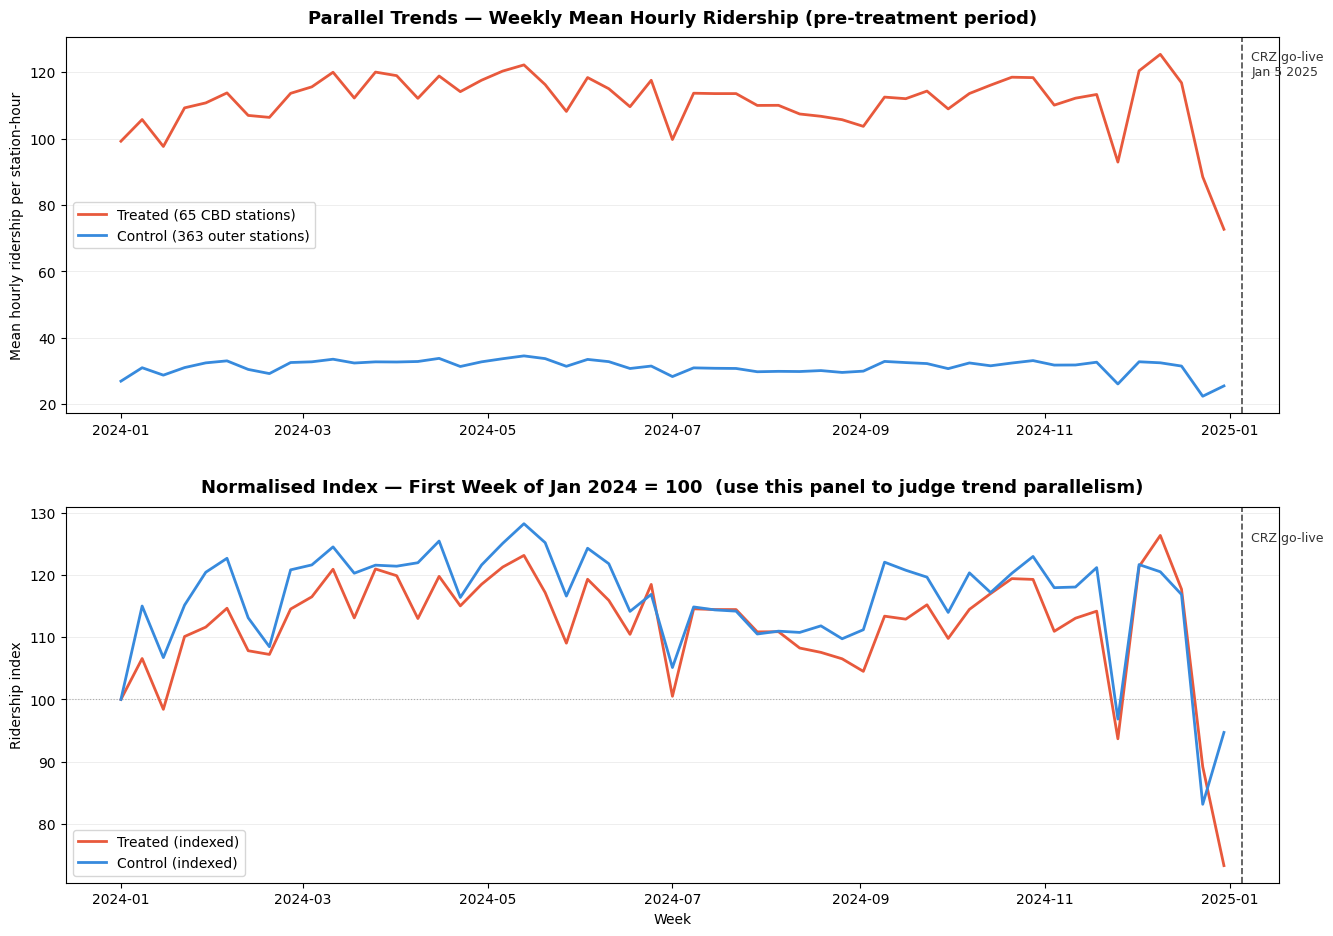

  Saved → /content/drive/MyDrive/MTA/clean_data/parallel_trends_visual.png

  Max normalised gap : 21.4 pts (week of 2024-12-30)
  ⚠️   Gap 21.4 pts > 10 — inspect the normalised plot carefully.

  ✅  Section 5 complete.


In [ ]:
section('5 · VISUAL PARALLEL TRENDS PLOT')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
weeks = weekly_treated.index

# ── Top: raw weekly means ─────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(weeks, weekly_treated.values, color='#E8593C', lw=2,
         label='Treated (65 CBD stations)', zorder=3)
ax1.plot(weeks, weekly_control.values, color='#378ADD', lw=2,
         label='Control (363 outer stations)', zorder=3)
ax1.axvline(CP_DATE, color='black', lw=1.2, ls='--', alpha=0.7)
ax1.text(CP_DATE + pd.Timedelta(days=3),
         ax1.get_ylim()[1] * 0.97,
         'CRZ go-live\nJan 5 2025', fontsize=9, va='top', color='#333')
ax1.set_title('Parallel Trends — Weekly Mean Hourly Ridership (pre-treatment period)',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Mean hourly ridership per station-hour', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3, lw=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Bottom: normalised index ──────────────────────────────────────────────────
ax2 = axes[1]
idx_treated = (weekly_treated / weekly_treated.iloc[0]) * 100
idx_control = (weekly_control / weekly_control.iloc[0]) * 100

ax2.plot(idx_treated.index, idx_treated.values, color='#E8593C', lw=2,
         label='Treated (indexed)', zorder=3)
ax2.plot(idx_control.index, idx_control.values, color='#378ADD', lw=2,
         label='Control (indexed)', zorder=3)
ax2.axhline(100, color='gray', lw=0.8, ls=':', alpha=0.6)
ax2.axvline(CP_DATE, color='black', lw=1.2, ls='--', alpha=0.7)
ax2.text(CP_DATE + pd.Timedelta(days=3),
         ax2.get_ylim()[1] * 0.97,
         'CRZ go-live', fontsize=9, va='top', color='#333')
ax2.set_title('Normalised Index — First Week of Jan 2024 = 100  '
              '(use this panel to judge trend parallelism)',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Ridership index', fontsize=10)
ax2.set_xlabel('Week', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout(pad=3)
plt.savefig(OUT_VISUAL_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {OUT_VISUAL_PNG}')

# Quantitative gap check
gap = (idx_treated - idx_control).abs()
max_gap      = gap.max()
max_gap_week = gap.idxmax()
print(f'\n  Max normalised gap : {max_gap:.1f} pts (week of {max_gap_week.date()})')
if max_gap > 10:
    print(f'  ⚠️   Gap {max_gap:.1f} pts > 10 — inspect the normalised plot carefully.')
else:
    print(f'  ✅  Gap {max_gap:.1f} pts < 10 — visual parallel trends looks good.')

print('\n  ✅  Section 5 complete.')

In [ ]:
section('6a · COLLAPSE TO DAILY STATION TOTALS')

print('  Collapsing hourly panel to daily station totals...')
daily = (
    df.groupby(['station_complex_id','Date','treated'])['ridership']
    .sum()
    .reset_index()
    .rename(columns={'ridership':'daily_ridership'})
)
print(f'  Daily panel : {len(daily):,} rows  '
      f'({daily["station_complex_id"].nunique()} stations × '
      f'{daily["Date"].nunique()} dates)')

check(
    abs(len(daily) - 428*730) < 5000,
    f'Daily panel {len(daily):,} rows — expected ~{428*730:,}. '
    'Some station-days may be missing or duplicated.',
    f'Daily panel shape {len(daily):,} ≈ expected {428*730:,} ✓'
)
print('\n  ✅  Section 6a complete.')


  6a · COLLAPSE TO DAILY STATION TOTALS
  Collapsing hourly panel to daily station totals...
  Daily panel : 310,536 rows  (428 stations × 731 dates)
  ✅  Daily panel shape 310,536 ≈ expected 312,440 ✓

  ✅  Section 6a complete.


In [ ]:
section('6b · CREATE MONTH × TREATED DUMMIES')

# month_num: 0=Jan2024 … 11=Dec2024 … 12=Jan2025 … 23=Dec2025
daily['month_num'] = (
    (daily['Date'].dt.year - 2024) * 12 + daily['Date'].dt.month - 1
)
months = sorted(daily['month_num'].unique())
print(f'  Month range     : {min(months)} (Jan 2024) → {max(months)} (Dec 2025)')
print(f'  Reference month : {REFERENCE_MONTH} (Dec 2024) — omitted, coeff = 0')

for m in months:
    if m == REFERENCE_MONTH:
        continue
    daily[f'dm_{m}'] = ((daily['month_num']==m) & (daily['treated']==1)).astype(int)

dummy_cols = [c for c in daily.columns if c.startswith('dm_')]
print(f'  Dummies created : {len(dummy_cols)}')

check(
    daily[dummy_cols].sum(axis=1).max() <= 1,
    'A row has more than one dummy active — dummies not mutually exclusive.',
    'Event-study dummies mutually exclusive ✓'
)
print('\n  ✅  Section 6b complete.')


  6b · CREATE MONTH × TREATED DUMMIES
  Month range     : 0 (Jan 2024) → 23 (Dec 2025)
  Reference month : 11 (Dec 2024) — omitted, coeff = 0
  Dummies created : 23
  ✅  Event-study dummies mutually exclusive ✓

  ✅  Section 6b complete.


In [ ]:
section('6c · RUN EVENT STUDY OLS')

print('  Within-demeaning by station to absorb station FE...')
daily['daily_ridership_dm'] = daily.groupby('station_complex_id')['daily_ridership'].transform(
    lambda x: x - x.mean()
)
for col in dummy_cols:
    daily[col+'_dm'] = daily.groupby('station_complex_id')[col].transform(
        lambda x: x - x.mean()
    )

dm_demeaned = [c+'_dm' for c in dummy_cols]
formula = 'daily_ridership_dm ~ ' + ' + '.join(dm_demeaned)

print('  Running OLS (~3–5 min)...')
event_model = smf.ols(formula, data=daily).fit(cov_type='HC3')
print(f'  OLS complete.  R² = {event_model.rsquared:.4f}')

# Extract and label coefficients
coefs = event_model.params.drop('Intercept')
cis   = event_model.conf_int().drop('Intercept')
pvals = event_model.pvalues.drop('Intercept')

def col_to_month(c):
    return int(c.replace('dm_','').replace('_dm',''))

results_event = pd.DataFrame({
    'month_num': [col_to_month(c) for c in coefs.index],
    'coef'     : coefs.values,
    'ci_low'   : cis[0].values,
    'ci_high'  : cis[1].values,
    'pval'     : pvals.values,
}).sort_values('month_num').reset_index(drop=True)

# Insert reference month at coeff = 0
ref = pd.DataFrame({'month_num':[REFERENCE_MONTH],'coef':[0.],'ci_low':[0.],'ci_high':[0.],'pval':[1.]})
results_event = pd.concat([results_event, ref]).sort_values('month_num').reset_index(drop=True)

MONTH_LABELS = {
     0:'Jan-24', 1:'Feb-24', 2:'Mar-24', 3:'Apr-24',
     4:'May-24', 5:'Jun-24', 6:'Jul-24', 7:'Aug-24',
     8:'Sep-24', 9:'Oct-24',10:'Nov-24',11:'Dec-24',
    12:'Jan-25',13:'Feb-25',14:'Mar-25',15:'Apr-25',
    16:'May-25',17:'Jun-25',18:'Jul-25',19:'Aug-25',
    20:'Sep-25',21:'Oct-25',22:'Nov-25',23:'Dec-25',
}
results_event['label'] = results_event['month_num'].map(MONTH_LABELS)

print('\n  Event study coefficients:')
print(results_event[['label','coef','ci_low','ci_high','pval']].to_string(index=False))
print('\n  ✅  Section 6c complete.')


  6c · RUN EVENT STUDY OLS
  Within-demeaning by station to absorb station FE...
  Running OLS (~3–5 min)...
  OLS complete.  R² = 0.1686

  Event study coefficients:
 label          coef        ci_low       ci_high          pval
Jan-24  -3597.145760  -4314.758884  -2879.532637  8.820619e-23
Feb-24  -2519.626973  -3261.193058  -1778.060887  2.749655e-11
Mar-24  -1760.764591  -2512.482681  -1009.046502  4.414158e-06
Apr-24  -1086.923557  -1849.003121   -324.843993  5.183263e-03
May-24   -559.219851  -1333.133459    214.693757  1.567040e-01
Jun-24  -1577.902018  -2331.264775   -824.539262  4.041361e-05
Jul-24  -2242.294020  -2979.598551  -1504.989490  2.512339e-09
Aug-24  -2700.391612  -3414.599694  -1986.183529  1.257825e-13
Sep-24   -494.553813  -1275.495784    286.388158  2.145307e-01
Oct-24   1230.520099    429.920386   2031.119813  2.591391e-03
Nov-24   -481.235352  -1257.486657    295.015954  2.243373e-01
Dec-24      0.000000      0.000000      0.000000  1.000000e+00
Jan-25 -10813


  7 · EVENT STUDY PLOT


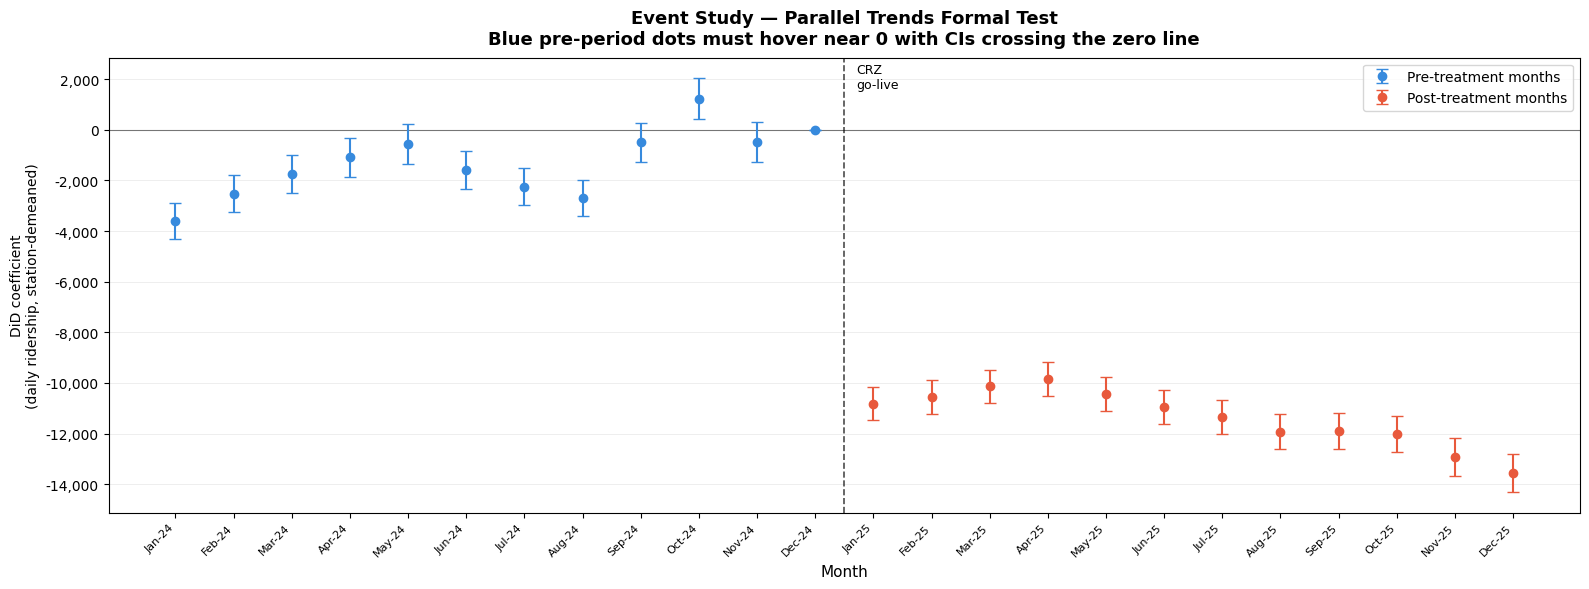

  Saved → /content/drive/MyDrive/MTA/clean_data/event_study_plot.png


In [ ]:
section('7 · EVENT STUDY PLOT')

pre_res  = results_event[results_event['month_num'] <  12]
post_res = results_event[results_event['month_num'] >= 12]

fig, ax = plt.subplots(figsize=(16, 6))
for subset, color, label in [
    (pre_res,  '#378ADD', 'Pre-treatment months'),
    (post_res, '#E8593C', 'Post-treatment months'),
]:
    ax.errorbar(
        subset['month_num'], subset['coef'],
        yerr=[subset['coef']-subset['ci_low'], subset['ci_high']-subset['coef']],
        fmt='o', color=color, ecolor=color, elinewidth=1.5,
        capsize=4, ms=6, label=label, zorder=3
    )
ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.5)
ax.axvline(11.5, color='black', lw=1.2, ls='--', alpha=0.7)
ax.text(11.7, ax.get_ylim()[1]*0.92, 'CRZ\ngo-live', fontsize=9, va='top')
ax.set_xticks(results_event['month_num'])
ax.set_xticklabels(results_event['label'], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('DiD coefficient\n(daily ridership, station-demeaned)', fontsize=10)
ax.set_title('Event Study — Parallel Trends Formal Test\n'
             'Blue pre-period dots must hover near 0 with CIs crossing the zero line',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(OUT_EVENTSTUDY_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {OUT_EVENTSTUDY_PNG}')

In [ ]:
section('7 · FORMAL PRE-TREND TESTS')

pre_coefs  = results_event[results_event['month_num'] < REFERENCE_MONTH]
post_coefs = results_event[results_event['month_num'] >= 12]

# ── Test 1: Individual significance ──────────────────────────────────────────
pre_sig = pre_coefs[pre_coefs['pval'] < 0.05]
print('  TEST 1 — Individual coefficient significance (pre-period)')
print(f'  Pre-period months tested : {len(pre_coefs)}')
print(f'  Significant (p<0.05)     : {len(pre_sig)}')
if len(pre_sig) > 0:
    print('\n  ⚠️   Significant pre-period months:')
    print(pre_sig[['label','coef','pval']].to_string(index=False))
    print('\n     Inspect the event study plot. If scattered, likely noise.')
    print('     If trending systematically, add quarterly controls.')
else:
    print('  ✅  No pre-period coefficients significant at p<0.05.')

# ── Test 2: Joint F-test ──────────────────────────────────────────────────────
print('\n  TEST 2 — Joint F-test (all pre-period coefficients = 0)')
pre_dm_cols = [f'dm_{m}_dm' for m in range(REFERENCE_MONTH)
               if f'dm_{m}_dm' in event_model.params.index]
joint_p = None
if len(pre_dm_cols) > 0:
    joint_test = event_model.f_test(' = '.join([f'{c} = 0' for c in pre_dm_cols]))
    joint_p    = float(joint_test.pvalue)
    print(f'  F-statistic : {float(joint_test.fvalue):.3f}')
    print(f'  p-value     : {joint_p:.4f}')
    if joint_p < 0.05:
        print(f'  ⚠️   Joint F p={joint_p:.4f} < 0.05 — pre-period jointly non-zero.')
        print('     Consider quarterly dummy controls for COVID/RTO seasonality.')
    else:
        print(f'  ✅  Joint F p={joint_p:.4f} ≥ 0.05 — pre-period jointly zero.')
else:
    print('  ⚠️   Could not run joint F-test — dummy columns not found.')

# ── Test 3: Direction check ───────────────────────────────────────────────────
post_mean = post_coefs['coef'].mean()
pre_mean  = pre_coefs['coef'].mean()
delta     = post_mean - pre_mean
print(f'\n  TEST 3 — Post vs pre coefficient mean')
print(f'  Pre-period mean  : {pre_mean:,.1f}')
print(f'  Post-period mean : {post_mean:,.1f}')
print(f'  Delta            : {delta:,.1f}')
if delta > 0:
    print('  ✅  Post-period mean higher than pre — consistent with positive CRZ effect.')
else:
    print('  ⚠️   Post-period mean lower than pre — check treated station ridership post-CRZ.')

print('\n  ✅  Section 7 complete.')


  7 · FORMAL PRE-TREND TESTS
  TEST 1 — Individual coefficient significance (pre-period)
  Pre-period months tested : 11
  Significant (p<0.05)     : 8

  ⚠️   Significant pre-period months:
 label         coef         pval
Jan-24 -3597.145760 8.820619e-23
Feb-24 -2519.626973 2.749655e-11
Mar-24 -1760.764591 4.414158e-06
Apr-24 -1086.923557 5.183263e-03
Jun-24 -1577.902018 4.041361e-05
Jul-24 -2242.294020 2.512339e-09
Aug-24 -2700.391612 1.257825e-13
Oct-24  1230.520099 2.591391e-03

     Inspect the event study plot. If scattered, likely noise.
     If trending systematically, add quarterly controls.

  TEST 2 — Joint F-test (all pre-period coefficients = 0)
  F-statistic : 28.032
  p-value     : 0.0000
  ⚠️   Joint F p=0.0000 < 0.05 — pre-period jointly non-zero.
     Consider quarterly dummy controls for COVID/RTO seasonality.

  TEST 3 — Post vs pre coefficient mean
  Pre-period mean  : -1,435.4
  Post-period mean : -11,369.8
  Delta            : -9,934.4
  ⚠️   Post-period mean l

In [ ]:
section('8 · FINAL VERDICT')

issues = []
if max_gap > 10:
    issues.append(f'Normalised index gap {max_gap:.1f} pts > 10 (Section 5)')
if len(pre_sig) > 0:
    issues.append(f'{len(pre_sig)} pre-period month(s) significant at p<0.05 (Section 7 Test 1)')
if joint_p is not None and joint_p < 0.05:
    issues.append(f'Joint F-test p={joint_p:.4f} < 0.05 (Section 7 Test 2)')

if len(issues) == 0:
    print('''
  ╔══════════════════════════════════════════════════════════════════╗
  ║  ✅  PARALLEL TRENDS: PASS                                       ║
  ║                                                                  ║
  ║  All checks passed. The DiD assumption is supported.             ║
  ║  Proceed to the Core DiD Regression.                            ║
  ╚══════════════════════════════════════════════════════════════════╝
''')
else:
    print('''
  ╔══════════════════════════════════════════════════════════════════╗
  ║  ⚠️   PARALLEL TRENDS: CONCERNS FLAGGED                          ║
  ║                                                                  ║
  ║  Review issues below before running DiD.                         ║
  ║  Disclose in write-up and add robustness checks.                 ║
  ╚══════════════════════════════════════════════════════════════════╝
''')
    for i, issue in enumerate(issues, 1):
        print(f'  Issue {i}: {issue}')

# Confirm output files
print('\n  Output files:')
for f in [OUT_PARALLEL_CSV, OUT_VISUAL_PNG, OUT_EVENTSTUDY_PNG]:
    exists = os.path.exists(f)
    print(f'  {"✅" if exists else "⚠️  NOT FOUND"}  {f.split("/")[-1]}')

print('''
  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_parallel_trends_weekly.csv  → feeds dashboard page 4
  parallel_trends_visual.png          → visual check (2 panels)
  event_study_plot.png                → formal event study plot
  ─────────────────────────────────────────────────────────────────
  NEXT STEPS
  ─────────────────────────────────────────────────────────────────
  PASS     → open MTA_CRZ_DiD_Analysis.ipynb and run the
             Core DiD Regression (PanelOLS with clustering)
  CONCERNS → inspect flagged issues, add quarterly dummy controls
             for COVID/RTO seasonality if needed, then re-run
  ─────────────────────────────────────────────────────────────────
''')


  8 · FINAL VERDICT

  ╔══════════════════════════════════════════════════════════════════╗
  ║  ⚠️   PARALLEL TRENDS: CONCERNS FLAGGED                          ║
  ║                                                                  ║
  ║  Review issues below before running DiD.                         ║
  ║  Disclose in write-up and add robustness checks.                 ║
  ╚══════════════════════════════════════════════════════════════════╝

  Issue 1: Normalised index gap 21.4 pts > 10 (Section 5)
  Issue 2: 8 pre-period month(s) significant at p<0.05 (Section 7 Test 1)
  Issue 3: Joint F-test p=0.0000 < 0.05 (Section 7 Test 2)

  Output files:
  ✅  mta_crz_parallel_trends_weekly.csv
  ✅  parallel_trends_visual.png
  ✅  event_study_plot.png

  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_parallel_trends_weekly.csv  → feeds dashboard page 4
  parallel_trends_visual.p